# Experiment 4: Binary Classification using Logistic Regression and SVM

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [ ]:
df=pd.read_csv("spambase_csv.csv")
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(4601, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report      

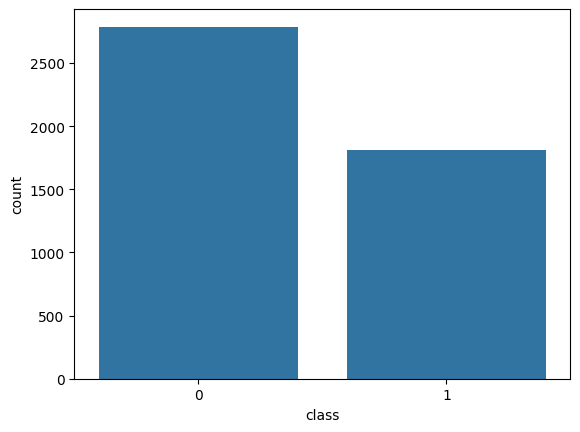

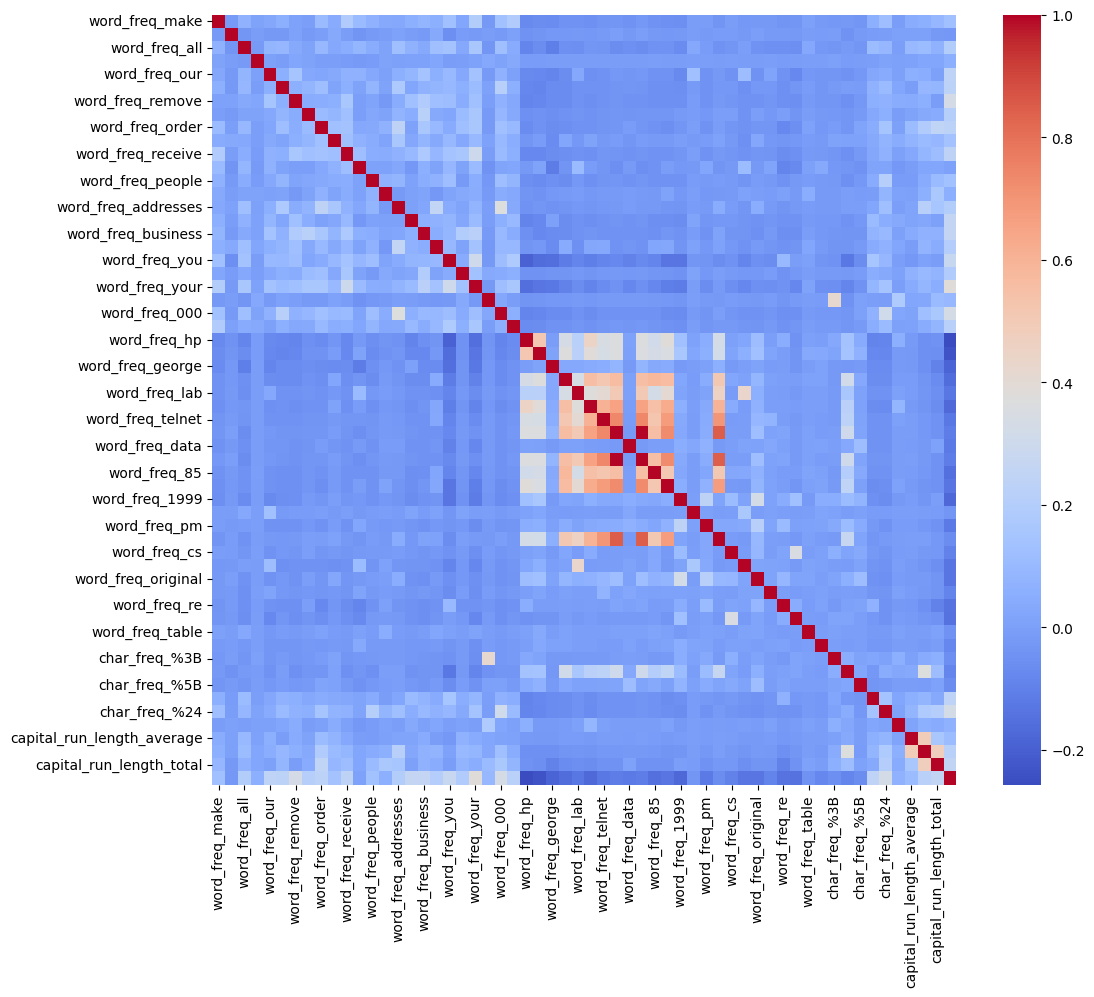

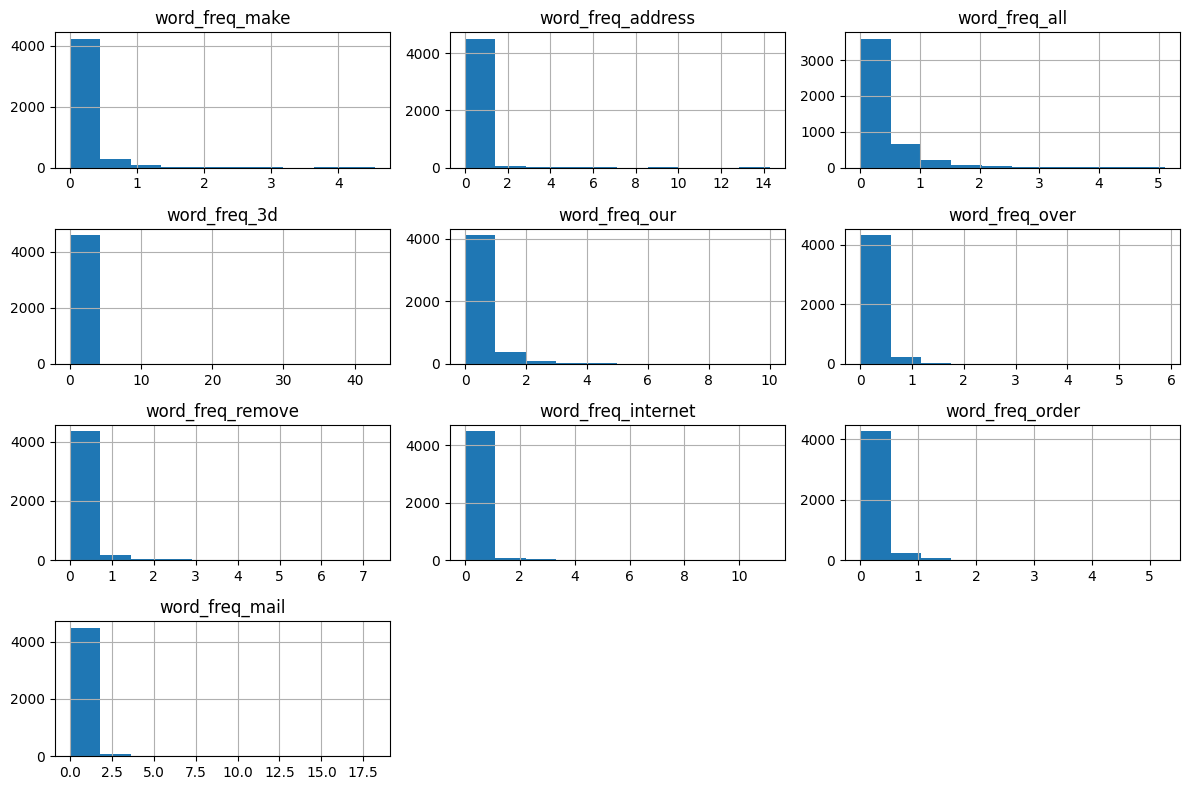

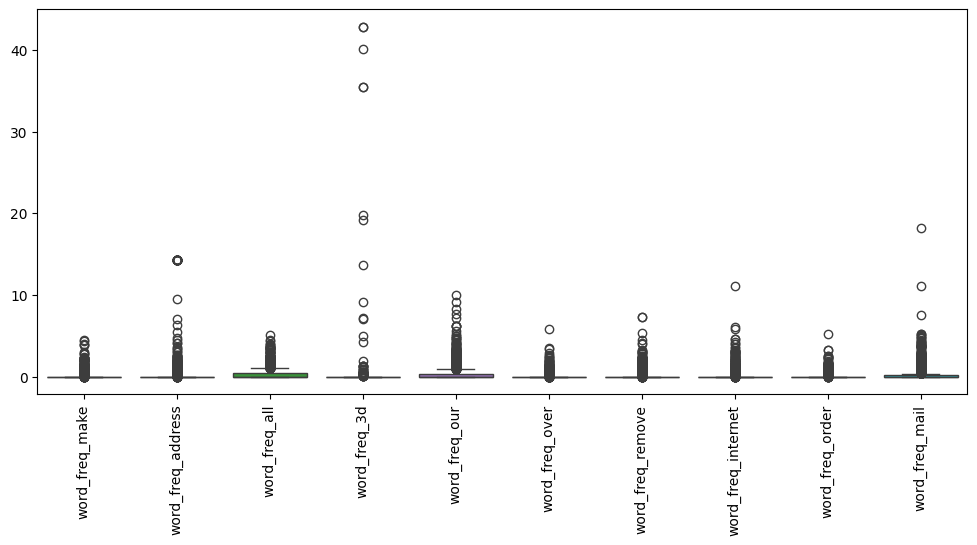

In [ ]:
sns.countplot(x="class",data=df)
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

df.iloc[:,:10].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=df.iloc[:,:10])
plt.xticks(rotation=90)
plt.show()

In [ ]:
X=df.drop("class",axis=1)
y=df["class"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

Accuracy 0.9196525515743756
Precision 0.9316939890710383
Recall 0.8743589743589744
F1 0.9021164021164021
Training Time 0.040529727935791016
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       531
           1       0.93      0.87      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



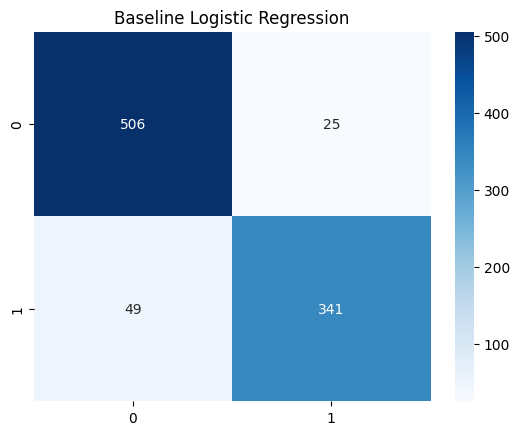

In [ ]:
start=time.time()
lr=LogisticRegression(max_iter=5000)
lr.fit(X_train,y_train)
lr_time=time.time()-start

pred=lr.predict(X_test)

print("Accuracy",accuracy_score(y_test,pred))
print("Precision",precision_score(y_test,pred))
print("Recall",recall_score(y_test,pred))
print("F1",f1_score(y_test,pred))
print("Training Time",lr_time)
print(classification_report(y_test,pred))

sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt="d",cmap="Blues")
plt.title("Baseline Logistic Regression")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              Metric       Value
0           Accuracy    0.917481
1          Precision    0.919786
2             Recall    0.882051
3           F1 Score    0.900524
4  Training Time (s)  528.176508
{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
0.9274456521739131


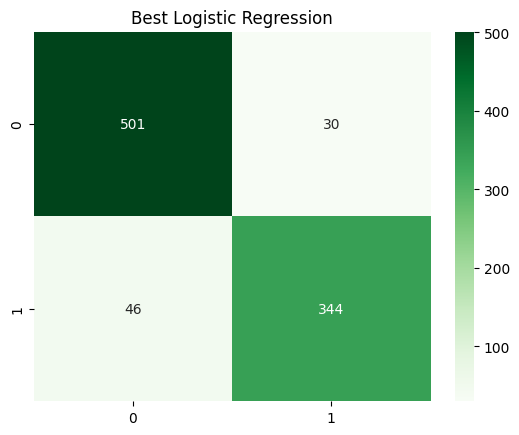

In [ ]:
params={
"penalty":["l1","l2"],
"C":[0.01,0.1,1,10,100],
"solver":["liblinear","saga"]
}

grid_lr=GridSearchCV(LogisticRegression(max_iter=5000),params,cv=5,scoring="accuracy")
start=time.time()
grid_lr.fit(X_train,y_train)
best_lr=grid_lr.best_estimator_
lr_best_time=time.time()-start

pred=best_lr.predict(X_test)

lr_results=pd.DataFrame({
"Metric":["Accuracy","Precision","Recall","F1 Score","Training Time (s)"],
"Value":[accuracy_score(y_test,pred),precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred),lr_best_time]
})
print(lr_results)
print(grid_lr.best_params_)
print(grid_lr.best_score_)

sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt="d",cmap="Greens")
plt.title("Best Logistic Regression")
plt.show()

In [ ]:
kernels=["linear","poly","rbf","sigmoid"]
rows=[]

for k in kernels:
    start=time.time()
    model=SVC(kernel=k)
    model.fit(X_train,y_train)
    t=time.time()-start
    pred=model.predict(X_test)
    rows.append([k,accuracy_score(y_test,pred),f1_score(y_test,pred),t])

kernel_df=pd.DataFrame(rows,columns=["Kernel","Accuracy","F1 Score","Training Time (s)"])
print(kernel_df)

    Kernel  Accuracy  F1 Score  Training Time (s)
0   linear  0.926167  0.910526           0.676201
1     poly  0.766558  0.633731           0.559421
2      rbf  0.934853  0.920635           0.285086
3  sigmoid  0.876221  0.850000           0.307000


              Metric       Value
0           Accuracy    0.934853
1          Precision    0.950820
2             Recall    0.892308
3           F1 Score    0.920635
4  Training Time (s)  796.104414
{'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
0.9307065217391305


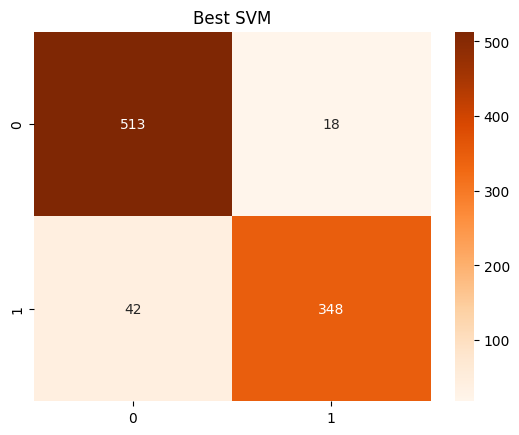

In [ ]:
params={
"kernel":["linear","poly","rbf","sigmoid"],
"C":[0.1,1,10,100],
"gamma":["scale","auto"],
"degree":[2,3,4]
}

grid_svm=GridSearchCV(SVC(),params,cv=5,scoring="accuracy")
start=time.time()
grid_svm.fit(X_train,y_train)
best_svm=grid_svm.best_estimator_
svm_time=time.time()-start

pred=best_svm.predict(X_test)

svm_results=pd.DataFrame({
"Metric":["Accuracy","Precision","Recall","F1 Score","Training Time (s)"],
"Value":[accuracy_score(y_test,pred),precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred),svm_time]
})
print(svm_results)
print(grid_svm.best_params_)
print(grid_svm.best_score_)

sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt="d",cmap="Oranges")
plt.title("Best SVM")
plt.show()

In [ ]:
lr_scores=cross_val_score(best_lr,X_train,y_train,cv=5)
svm_scores=cross_val_score(best_svm,X_train,y_train,cv=5)

cv_df=pd.DataFrame({
"Fold":["Fold 1","Fold 2","Fold 3","Fold 4","Fold 5","Average"],
"Logistic Regression":list(lr_scores)+[lr_scores.mean()],
"SVM":list(svm_scores)+[svm_scores.mean()]
})
print(cv_df)

tuning_df=pd.DataFrame({
"Model":["Logistic Regression","SVM"],
"Search Method":["Grid Search","Grid Search"],
"Best Parameters":[str(grid_lr.best_params_),str(grid_svm.best_params_)],
"Best CV Accuracy":[grid_lr.best_score_,grid_svm.best_score_]
})
print(tuning_df)

comparison=pd.DataFrame({
"Criterion":["Accuracy","Model Complexity","Training Time","Interpretability"],
"Logistic Regression":[
accuracy_score(y_test,best_lr.predict(X_test)),
"Low",
lr_best_time,
"High"
],
"SVM":[
accuracy_score(y_test,best_svm.predict(X_test)),
"High",
svm_time,
"Low"
]
})
print(comparison)

      Fold  Logistic Regression       SVM
0   Fold 1             0.937500  0.934783
1   Fold 2             0.904891  0.904891
2   Fold 3             0.933424  0.940217
3   Fold 4             0.930707  0.937500
4   Fold 5             0.930707  0.936141
5  Average             0.927446  0.930707
                 Model Search Method  \
0  Logistic Regression   Grid Search   
1                  SVM   Grid Search   

                                     Best Parameters  Best CV Accuracy  
0  {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}          0.927446  
1  {'C': 1, 'degree': 2, 'gamma': 'scale', 'kerne...          0.930707  
          Criterion Logistic Regression         SVM
0          Accuracy            0.917481    0.934853
1  Model Complexity                 Low        High
2     Training Time          528.176508  796.104414
3  Interpretability                High         Low
